# Modelo de Detecção de Anomalia em Fundos de Investimento

### MVP: Machine Learning & Analytics

**Nome:** Felipe Ramos Pinheiro

**Matrícula:** 202600

**Data:** 27/06/2026

**Dataset:** [Informe Diário de Fundos de Investimento (CVM)](https://dados.cvm.gov.br/dataset/fi-doc-inf_diario)

**Tipo de problema:** Detecção de Anomalias (não supervisionado)

---

# 1. Definição do problema

## 1.1 Descrição do problema

**O problema:** o projeto detecta fundos de investimento com comportamento atípico usando dados públicos da CVM. A CVM publica diariamente os dados de todos os fundos registrados no Brasil: valor da cota, patrimônio, captação, resgate e número de cotistas.

**Por que importa:** o Brasil tem mais de 20 mil fundos ativos. Nenhuma equipe os monitora individualmente. O modelo lê o histórico de cada fundo e sinaliza os que apresentam combinações incomuns de indicadores: queda de cota, perda de cotistas e redução de patrimônio simultâneas.

**A lógica da detecção:** um indicador isolado pode ser normal. A combinação de vários sinais negativos ao mesmo tempo indica comportamento atípico.

## 1.2 Objetivo do MVP

**Objetivo:** atribuir a cada fundo um **score de anomalia**, um número que indica o quanto o comportamento do fundo destoa do restante do mercado. Quanto maior o score, mais atípico o fundo.

**Uso pretendido:** os fundos com scores mais altos viram candidatos prioritários para due diligence, monitoramento ou exclusão de carteiras de recomendação.

**Como funciona:** o modelo não usa exemplos de fundos problemáticos. Ele calcula indicadores sobre o histórico de todos os fundos e sinaliza os que se afastam do padrão do conjunto.

## 1.3 Tipo de problema

**Tipo:** Detecção de anomalias (aprendizado não supervisionado)

**Motivação:**
- Os dados públicos da CVM não incluem uma lista de fundos problemáticos. Sem rótulos, o projeto não treina um classificador supervisionado.
- O modelo calcula a distribuição dos indicadores para todos os fundos e atribui scores altos aos que se afastam do padrão do conjunto.
- Isolation Forest e Local Outlier Factor são os algoritmos mais usados para detecção de anomalias em dados financeiros tabulares.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas:**
- Os dados públicos da CVM descrevem o comportamento de cada fundo sem precisar de dados proprietários.
- Anomalias são eventos raros: a maioria dos fundos opera dentro dos padrões do mercado.
- Indicadores derivados da série temporal (volatilidade, drawdown, tendência de PL e cotistas, fluxo) capturam os sinais mais relevantes de comportamento atípico.

**Hipóteses:**
1. Fundos com problemas operacionais ou em processo de liquidação mostram queda de PL, redução de cotistas e fluxo líquido negativo persistente ao mesmo tempo.
2. Fundos com volatilidade ou drawdown muito acima da média desviam do padrão esperado para fundos regulados.
3. A combinação de múltiplos indicadores detecta mais casos do que flags univariados. Um fundo pode ter volatilidade alta sem ser anômalo; volatilidade alta combinada com queda de cotistas e drawdown extremo é um sinal muito mais forte.

**Critérios de sucesso:**
- Distribuição assimétrica dos scores, com cauda à direita: indica fundos genuinamente destoantes.
- Perfil médio dos fundos anômalos coerente com dificuldades: drawdown extremo, cotistas em queda, PL em declínio.
- Concordância razoável entre Isolation Forest e LOF: valida que os fundos sinalizados não são artefatos de um único algoritmo.
- Notebook executa do início ao fim no Google Colab sem configuração manual.

# 2. Ambiente, bibliotecas e reprodutibilidade

**Bibliotecas:** todas padrão da stack científica Python, disponíveis por padrão no Google Colab. O notebook não exige instalação manual.

**Reprodutibilidade:** o notebook fixa a semente `SEED = 42` em todos os modelos com aleatoriedade. Qualquer pessoa que execute o notebook obtém exatamente os mesmos resultados.

In [59]:
import gc
import pickle
import time
import zipfile
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [60]:
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

In [61]:
RAW_DIR = Path("cvm_mvp_data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

## 2.1 Função de download e leitura

**Função `carregar_mes(ym)`:** baixa e lê cada arquivo mensal da CVM. Se o arquivo já estiver na pasta local, a função pula o download.

**Otimização de memória:** o parâmetro `usecols` carrega apenas as 7 colunas necessárias. Isso reduz o uso de memória frente à carga da tabela completa.

In [62]:
# Colunas alvo: inclui CNPJ_FUNDO (nome pré-RCVM 175) e CNPJ_FUNDO_CLASSE (pós-RCVM 175)
# A lambda no usecols ignora silenciosamente as que não existem no arquivo
COLS = [
    "CNPJ_FUNDO_CLASSE", "CNPJ_FUNDO",   # identificador — nome mudou com RCVM 175
    "TP_FUNDO_CLASSE",                     # tipo — ausente em arquivos antigos
    "DT_COMPTC", "VL_QUOTA", "VL_PATRIM_LIQ", "CAPTC_DIA", "RESG_DIA", "NR_COTST",
]
COLS_SET = set(COLS)

In [63]:
def carregar_mes(ym):
    url  = f"https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_{ym}.zip"
    path = RAW_DIR / f"inf_diario_fi_{ym}.zip"
    if not path.exists():
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        path.write_bytes(r.content)
    with zipfile.ZipFile(path) as zf:
        csv = [n for n in zf.namelist() if n.endswith(".csv")][0]
        with zf.open(csv) as f:
            return pd.read_csv(f, sep=";", encoding="latin1",
                               usecols=lambda c: c in COLS_SET,
                               low_memory=False)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** Informe Diário de Fundos de Investimento, publicado pela CVM em dados abertos. URL: https://dados.cvm.gov.br/dataset/fi-doc-inf_diario. O notebook baixa os arquivos por URL pública, sem login, token ou upload manual.
Este dataset é o único conjunto público com dados diários de retorno, patrimônio, captação, resgate e número de cotistas para todos os fundos registrados no Brasil.

**Recorte temporal:** dezembro de 2023 a junho de 2026, 30 meses, 630 pregões.
  - O ponto de partida evita o choque de juros de 2021 a 2022, quando a Selic subiu de 2% para 13,75% em 18 meses. Fundos de renda fixa perderam valor por razões macroeconômicas, não operacionais, nesse período.
  - Dezembro de 2023 marca o início efetivo porque a Resolução CVM 175 introduziu o campo `TP_FUNDO_CLASSE` nos informes. Arquivos anteriores não têm esse campo.
  - A Selic ficou entre 10% e 14,5% durante toda a janela. Isso torna os fundos comparáveis entre si.
  - Consumo de memória: aproximadamente 200 MB.

**Filtro por tipo:** o notebook mantém apenas fundos FIF (Fundo de Investimento Financeiro).
  - Com a Resolução CVM 175, o campo passou de `"FI"` para `"CLASSES - FIF"` nos informes a partir de 2024. O filtro usa `isin({"FI", "CLASSES - FIF"})` para cobrir as duas nomenclaturas.
  - O filtro exclui FII, FIP e FIDC porque têm regras e perfis de risco distintos.

**Colunas selecionadas:** apenas as 8 necessárias para os indicadores, via `usecols`.

**Dados pessoais:** nenhum. Os dados são institucionais, referentes a fundos registrados na CVM.

## 3.2 Carga dos dados

O código abaixo baixa os arquivos mensais da CVM e consolida tudo em um único DataFrame. Cada linha representa um fundo em uma data específica.

- **Recorte temporal (12/2023 - 06/2026):** a Resolução CVM 175 introduziu o campo `TP_FUNDO_CLASSE` nos informes diários a partir de out/2023. Arquivos anteriores não têm esse campo, e o filtro os descartaria de qualquer forma; por isso baixar esses arquivos não compensa. A janela também evita o choque de juros de 2021 a 2022, quando a Selic subiu de 2% para 13,75% em 18 meses e fundos de renda fixa perderam valor por razões macroeconômicas, não por problemas de gestão.
- **Filtro por tipo (`TIPOS_FIF = {"FI", "CLASSES - FIF"}`):** a partir de 2024, os informes da RCVM 175 passaram a registrar o tipo `"FI"` como `"CLASSES - FIF"`. O filtro inclui as duas nomenclaturas para cobrir toda a janela. O filtro exclui FII, FIP e FIDC porque têm regras e perfis de risco distintos.

In [64]:
DATA_INICIO = "2023-12"
DATA_FIM    = "2026-06"
MESES = pd.period_range(DATA_INICIO, DATA_FIM, freq="M").strftime("%Y%m").tolist()

In [65]:
frames = []
for ym in MESES:
    chunk = carregar_mes(ym)
    frames.append(chunk)
    print(f"{ym}: {len(chunk):,} linhas")

df = pd.concat(frames, ignore_index=True)
del frames; gc.collect()

202312: 514,295 linhas
202401: 567,834 linhas
202402: 491,206 linhas
202403: 517,245 linhas
202404: 569,499 linhas
202405: 543,625 linhas
202406: 517,137 linhas
202407: 593,746 linhas
202408: 565,953 linhas
202409: 538,493 linhas
202410: 593,077 linhas
202411: 486,428 linhas
202412: 539,104 linhas
202501: 560,718 linhas
202502: 512,125 linhas
202503: 488,025 linhas
202504: 508,731 linhas
202505: 531,278 linhas
202506: 516,180 linhas
202507: 579,610 linhas
202508: 527,241 linhas
202509: 551,716 linhas
202510: 577,068 linhas
202511: 477,056 linhas
202512: 556,169 linhas
202601: 532,401 linhas
202602: 457,474 linhas
202603: 560,852 linhas
202604: 509,165 linhas
202605: 508,023 linhas
202606: 520,827 linhas


0

In [66]:
n_total = df["CNPJ_FUNDO_CLASSE"].nunique()
TIPOS_FIF = {"FI", "CLASSES - FIF"}
df = df[df["TP_FUNDO_CLASSE"].isin(TIPOS_FIF)].copy()
n_FI = df["CNPJ_FUNDO_CLASSE"].nunique()
print(f"\nFiltro FI: {n_FI:,} fundos retidos de {n_total:,} totais ({n_FI/n_total:.1%})")
df = df.drop(columns=["TP_FUNDO_CLASSE"])


Filtro FI: 33,747 fundos retidos de 33,760 totais (100.0%)


In [67]:
df["DT_COMPTC"] = pd.to_datetime(df["DT_COMPTC"], errors="coerce")
for col in ["VL_QUOTA", "VL_PATRIM_LIQ", "CAPTC_DIA", "RESG_DIA", "NR_COTST"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Total: {len(df):,} linhas  |  {df['CNPJ_FUNDO_CLASSE'].nunique():,} fundos únicos")
print(f"Período carregado: {df['DT_COMPTC'].min().date()} → {df['DT_COMPTC'].max().date()}")

Total: 16,503,894 linhas  |  33,747 fundos únicos
Período carregado: 2023-12-01 → 2026-06-30


## 3.3 Visão geral do dataset

A tabela resume o volume de dados carregados e a taxa de valores ausentes por coluna.

In [68]:
print(f"Registros : {len(df):,}")
print(f"Fundos    : {df['CNPJ_FUNDO_CLASSE'].nunique():,}")
print(f"Período   : {df['DT_COMPTC'].min().date()} → {df['DT_COMPTC'].max().date()}")

display(df.head())
display(pd.DataFrame({
    "ausentes": df.isna().sum(),
    "taxa": df.isna().mean().map("{:.1%}".format),
}))

Registros : 16,503,894
Fundos    : 33,747
Período   : 2023-12-01 → 2026-06-30


,CNPJ_FUNDO_CLASSE,DT_COMPTC,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,00.017.024/0001-53,2023-12-01,34.042625,1133992.17,0.0,0.0,1
1,00.017.024/0001-53,2023-12-04,34.055502,1134421.12,0.0,0.0,1
2,00.017.024/0001-53,2023-12-05,34.068554,1134855.89,0.0,0.0,1
3,00.017.024/0001-53,2023-12-06,34.081344,1135281.94,0.0,0.0,1
4,00.017.024/0001-53,2023-12-07,34.094473,1135719.27,0.0,0.0,1


,ausentes,taxa
CNPJ_FUNDO_CLASSE,0,0.0%
DT_COMPTC,0,0.0%
VL_QUOTA,0,0.0%
VL_PATRIM_LIQ,0,0.0%
CAPTC_DIA,0,0.0%
RESG_DIA,0,0.0%
NR_COTST,0,0.0%


## 3.4 Dicionário de dados

| Coluna | Tipo | O que representa | Usada no modelo? |
| --- | --- | --- | --- |
| CNPJ_FUNDO_CLASSE | texto | Identificador único do fundo. A Resolução CVM 175 substituiu o CNPJ_FUNDO por este campo nos informes mais recentes. | Sim, como chave |
| DT_COMPTC | data | Data de competência do registro diário. | Sim |
| VL_QUOTA | número | Valor da cota na data. Base para calcular retorno diário, drawdown e retorno acumulado. | Sim |
| VL_PATRIM_LIQ | número | Patrimônio líquido do fundo na data. Indica o tamanho do fundo e sua evolução ao longo do tempo. | Sim |
| CAPTC_DIA | número | Total de aplicações recebidas no dia. | Sim |
| RESG_DIA | número | Total de resgates pagos no dia. | Sim |
| NR_COTST | número | Número de cotistas do fundo na data. | Sim |
| TP_FUNDO_CLASSE | texto | Tipo do fundo (FI, FII, FIDC etc.). Usado apenas no filtro inicial; não entra nos indicadores. | Não |

## 3.5 Cadastro de fundos (CVM)

A CVM publica o arquivo `registro_fundo_classe.zip` com informações cadastrais de cada classe de fundo: nome, situação (ativa, em liquidação, cancelada), classificação ANBIMA e público-alvo (Público Geral, Profissional, Qualificado).

O cadastro alimenta três etapas:
1. **Seção 5.3:** o código remove da modelagem as classes com situação diferente de "Em Funcionamento Normal" e mantém apenas fundos em operação ativa.
2. **Seções 6.1 e 10.3:** a normalização e o Isolation Forest por peer group combinam categoria ANBIMA e público-alvo. Isso elimina comparações entre fundos de perfil de risco ou de investidor distintos.

In [69]:
cad = None  # fallback: o modelo roda normalmente sem o cadastro

try:
    ZIP_PATH = RAW_DIR / "registro_fundo_classe.zip"
    if not ZIP_PATH.exists():
        r = requests.get(
            "https://dados.cvm.gov.br/dados/FI/CAD/DADOS/registro_fundo_classe.zip",
            timeout=120,
        )
        r.raise_for_status()
        ZIP_PATH.write_bytes(r.content)

    with zipfile.ZipFile(ZIP_PATH) as zf:
        with zf.open("registro_classe.csv") as f:
            cad_raw = pd.read_csv(f, sep=";", encoding="latin1", low_memory=False)

    print(f"registro_classe.csv: {len(cad_raw):,} classes | colunas: {len(cad_raw.columns)}")

    cad = (cad_raw[["CNPJ_Classe", "Denominacao_Social", "Situacao", "Classificacao_Anbima", "Publico_Alvo"]]
           .copy()
           .rename(columns={
               "CNPJ_Classe"          : "CNPJ_FUNDO_CLASSE",
               "Denominacao_Social"   : "nome",
               "Situacao"             : "situacao",
               "Classificacao_Anbima" : "tipo",
               "Publico_Alvo"         : "publico_alvo",
           })
           .drop_duplicates("CNPJ_FUNDO_CLASSE"))

    # Normaliza CNPJ para o join: remove pontuação e zero-pad a 14 dígitos
    cad["_cnpj_norm"] = (cad["CNPJ_FUNDO_CLASSE"].astype(str)
                         .str.replace(r"\D", "", regex=True)
                         .str.zfill(14))

    print(f"Cadastro carregado: {len(cad):,} classes")
    print(f"Exemplo de normalização: '{cad['CNPJ_FUNDO_CLASSE'].iloc[0]}' → '{cad['_cnpj_norm'].iloc[0]}'")
    print("\nSituação das classes:")
    display(cad["situacao"].value_counts())
    print("\nClassificação ANBIMA (top 15):")
    display(cad["tipo"].value_counts().head(15))
    print("\nPúblico-alvo:")
    display(cad["publico_alvo"].value_counts())

except Exception as e:
    print(f"Atenção: cadastro CVM não carregado — {e}")
    print("O modelo continuará sobre todos os registros dos informes sem enriquecimento de metadados.")

registro_classe.csv: 36,336 classes | colunas: 30
Cadastro carregado: 36,323 classes
Exemplo de normalização: '332266000131' → '00332266000131'

Situação das classes:


,count
situacao,
Em Funcionamento Normal,33432
Fase Pré-Operacional,2235
Em Liquidação,620
Cancelado,36



Classificação ANBIMA (top 15):


,count
tipo,
Multimercados Invest. no Exterior,5442
Multimercados Livre,4377
Renda Fixa Duração Livre Crédito Livre,3317
Previdência Multimercado Livre,2663
Ações Livre,2107
Ações Invest. no Exterior,1198
Renda Fixa Duração Livre Grau de Invest.,907
Multimercados Macro,727
Renda Fixa Duração Baixa Grau de Invest.,516



Público-alvo:


,count
publico_alvo,
Profissional,16786
Público Geral,5598
Qualificado,3814


# 4. Análise exploratória dos dados


In [70]:
display(df[["VL_QUOTA", "VL_PATRIM_LIQ", "CAPTC_DIA", "RESG_DIA", "NR_COTST"]].describe().round(2).T)

,count,mean,std,min,25%,50%,75%,max
VL_QUOTA,16503894.0,4.657477e+04,5.323201e+07,-2.165812e+07,1.25,2.14,2.452000e+01,1.231903e+11
VL_PATRIM_LIQ,16503894.0,4.819236e+08,8.032859e+09,-1.111061e+12,15857031.92,44849227.64,1.599230e+08,1.668177e+13
CAPTC_DIA,16503894.0,2.862135e+06,6.160005e+07,0.000000e+00,0.00,0.00,0.000000e+00,2.910873e+10
RESG_DIA,16503894.0,2.882905e+06,6.233695e+07,0.000000e+00,0.00,0.00,0.000000e+00,4.913206e+10
NR_COTST,16503894.0,1.008720e+03,1.525787e+04,0.000000e+00,1.00,2.00,1.500000e+01,1.188504e+06


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


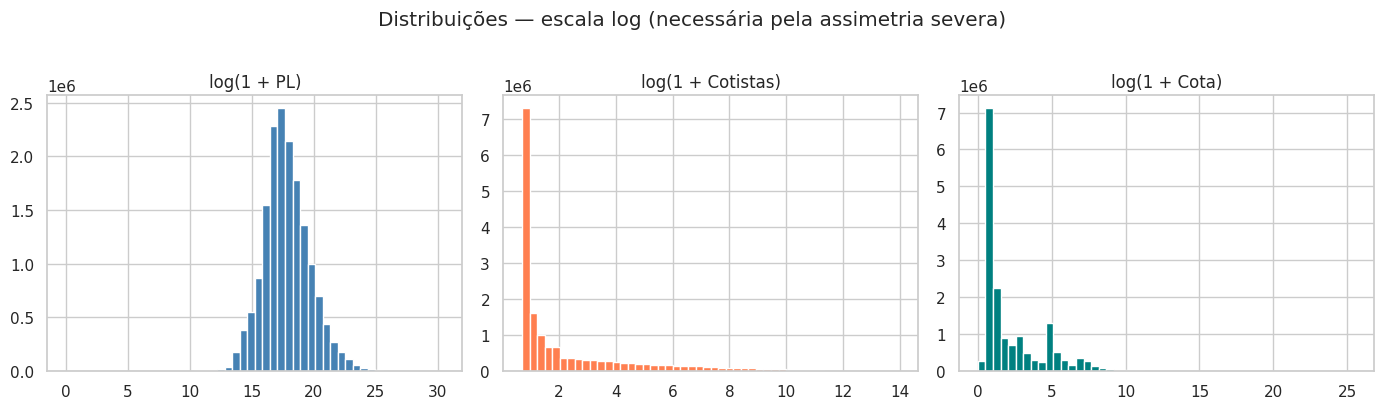

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label, color in zip(
    axes,
    ["VL_PATRIM_LIQ", "NR_COTST", "VL_QUOTA"],
    ["log(1 + PL)", "log(1 + Cotistas)", "log(1 + Cota)"],
    ["steelblue", "coral", "teal"],
):
    vals = np.log1p(df[col].dropna())
    ax.hist(vals[vals > 0], bins=50, color=color, edgecolor="white")
    ax.set_title(label)
plt.suptitle("Distribuições — escala log (necessária pela assimetria severa)", y=1.02)
plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

Os gráficos acima mostram a distribuição dos indicadores `"VL_PATRIM_LIQ"`, `"NR_COTST"` e `"VL_QUOTA"` entre todos os fundos, na escala `log(1 + valor)`. O eixo horizontal é o valor do indicador; o eixo vertical é o número de fundos com aquele valor.

A transformação logarítmica é necessária porque as distribuições são fortemente assimétricas. A maioria dos fundos tem patrimônio abaixo de R$ 50 milhões, mas alguns fundos têm PL acima de `R$ 10 bilhões`. Na escala original, esses valores extremos comprimem a visualização e tornam o gráfico ilegível.

**Principais achados:**

- **Valores ausentes:** baixos em `VL_QUOTA` e `VL_PATRIM_LIQ`. `CAPTC_DIA` e `RESG_DIA` mostram zeros nos dias sem movimentação, o que é esperado. O pipeline preenche os valores ausentes pela mediana.
- **Assimetria severa em PL e cotistas:** a transformação `log1p` evita que fundos grandes dominem os algoritmos de distância.
- **Cauda longa:** fundos com PL muito baixo ou número de cotistas próximo de zero podem estar em processo de esvaziamento.
- **Fluxo:** o indicador `prop_fluxo_neg`, definido na seção 5, captura os dias em que o resgate supera a captação. Proporções altas indicam estresse.

# 5. Preparação dos dados

## 5.1 Justificativa da preparação

Em detecção de anomalias, o modelo não tem variável-alvo e não divide os dados em treino e teste. O modelo ajusta sobre toda a base e atribui um score a cada observação. A avaliação usa a interpretabilidade econômica dos fundos sinalizados e a concordância entre algoritmos.

**10 indicadores por fundo, cada um mede um sinal de estresse diferente:**

| Indicador | O que mede | Sinal de anomalia |
|---|---|---|
| `volatilidade` | Desvio padrão anualizado dos retornos diários | Muito acima da média do mercado |
| `retorno_total` | Variação da cota do início ao fim do período | Muito negativo |
| `max_drawdown` | Pior queda da cota em relação ao pico histórico | Muito negativo |
| `sharpe` | Retorno por unidade de risco (retorno / volatilidade) | Muito negativo: o fundo perde valor com alta volatilidade |
| `log_pl` | Patrimônio médio do fundo em escala logarítmica | Muito baixo: fundo pequeno ou esvaziando |
| `fluxo_medio` | Captação líquida média diária | Muito negativo: saídas persistentes |
| `prop_fluxo_neg` | Proporção de dias com resgate superior à captação | Próxima de 1: cotistas em saída persistente |
| `tendencia_pl` | Variação do PL em escala log do início para o fim | Muito negativa: patrimônio em declínio |
| `tendencia_cotistas` | Variação de cotistas em escala log do início para o fim | Muito negativa: base de cotistas diminuindo |
| `log_cotistas` | Número médio de cotistas em escala logarítmica | Muito baixo |

**Decisões desta etapa:**
- **`MIN_OBS = 500`:** exclui fundos com histórico insuficiente para calcular tendências, Sharpe e volatilidade com confiança. A janela tem 30 meses e 630 pregões; 500 observações cobrem 79% do período, o que garante que o fundo esteve ativo na maior parte da janela.
- **`sharpe`:** calculado como `retorno_total / volatilidade`. Fundos com retorno negativo e alta volatilidade ficam fortemente negativos. Volatilidade zero gera `NaN`, e o pipeline preenche esse valor pela mediana.
- **`prop_fluxo_neg`:** média de uma coluna binária 0/1. O cálculo é vetorizado; não usa `.apply()`.
- **`tendencia_pl` e `tendencia_cotistas`:** diferença em escala log entre o último e o primeiro valor. Capturam declínio persistente, não o nível médio.
- **Sem data leakage:** o pipeline ajusta sobre toda a feature matrix, prática padrão em detecção de anomalias sem alvo supervisionado.

In [72]:
MIN_OBS = 500

df = df.sort_values(["CNPJ_FUNDO_CLASSE", "DT_COMPTC"])

In [73]:
# Features derivadas — vetorizadas
df["retorno"]   = df.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"].pct_change()
df["fluxo"]     = df["CAPTC_DIA"] - df["RESG_DIA"]
df["drawdown"]  = df["VL_QUOTA"] / df.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"].cummax() - 1
df["fluxo_neg"] = (df["fluxo"] < 0).astype("int8")   # 1 se resgate > captação no dia

In [74]:
# Filtrar fundos com histórico mínimo
obs = df.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"].count()
df  = df[df["CNPJ_FUNDO_CLASSE"].isin(obs[obs >= MIN_OBS].index)]

In [75]:
# Agregar: uma linha por fundo
agg = df.groupby("CNPJ_FUNDO_CLASSE").agg(
    retorno_std    = ("retorno",      "std"),
    max_drawdown   = ("drawdown",     "min"),
    pl_medio       = ("VL_PATRIM_LIQ","mean"),
    pl_ini         = ("VL_PATRIM_LIQ","first"),
    pl_fim         = ("VL_PATRIM_LIQ","last"),
    fluxo_medio    = ("fluxo",        "mean"),
    prop_fluxo_neg = ("fluxo_neg",    "mean"),
    cotistas_ini   = ("NR_COTST",     "first"),
    cotistas_fim   = ("NR_COTST",     "last"),
    cotistas_med   = ("NR_COTST",     "mean"),
    quota_ini      = ("VL_QUOTA",     "first"),
    quota_fim      = ("VL_QUOTA",     "last"),
).reset_index()

In [76]:
features = agg.copy()
features["volatilidade"]       = features["retorno_std"] * np.sqrt(252)
features["retorno_total"]      = features["quota_fim"] / features["quota_ini"] - 1
features["sharpe"]             = features["retorno_total"] / features["volatilidade"].replace(0, np.nan)
features["log_pl"]             = np.log1p(features["pl_medio"])
features["log_cotistas"]       = np.log1p(features["cotistas_med"])
features["tendencia_pl"]       = np.log1p(features["pl_fim"]) - np.log1p(features["pl_ini"])
features["tendencia_cotistas"] = np.log1p(features["cotistas_fim"]) - np.log1p(features["cotistas_ini"])

features = features.drop(columns=[
    "retorno_std", "pl_medio", "pl_ini", "pl_fim",
    "cotistas_med", "cotistas_ini", "cotistas_fim", "quota_ini", "quota_fim",
])
features = features.replace([np.inf, -np.inf], np.nan)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [77]:
del df, agg; gc.collect()
print(f"Feature matrix: {features.shape}")
display(features.describe().round(4).T)

Feature matrix: (20949, 11)


,count,mean,std,min,25%,50%,75%,max
max_drawdown,20949.0,-3.743800e+00,5.138841e+02,-7.437612e+04,-0.1652,-0.0546,-0.0128,0.000000e+00
fluxo_medio,20949.0,-6.059205e+04,2.383850e+06,-6.857660e+07,-83611.4767,-8730.3156,7241.5369,1.077093e+08
prop_fluxo_neg,20949.0,1.900000e-01,2.502000e-01,0.000000e+00,0.0076,0.0480,0.3292,1.000000e+00
volatilidade,20682.0,1.427878e+06,2.002398e+08,5.000000e-04,0.0180,0.0498,0.1484,2.879593e+10
retorno_total,20927.0,1.250130e+01,1.367269e+03,-6.189990e+01,0.1920,0.2958,0.3633,1.896109e+05
sharpe,20682.0,3.672280e+01,7.975210e+01,-4.418810e+01,1.7990,5.4632,17.6541,4.200063e+02
log_pl,20935.0,1.804830e+01,1.784100e+00,9.040000e-01,16.8425,17.8540,19.1041,2.602720e+01
log_cotistas,20949.0,2.303000e+00,2.331000e+00,2.517000e-01,0.6931,1.1002,3.1454,1.361390e+01
tendencia_pl,20919.0,-8.289000e-01,4.074500e+00,-2.405430e+01,-0.7051,-0.0214,0.3543,2.105720e+01
tendencia_cotistas,20949.0,-7.140000e-02,1.053400e+00,-1.005510e+01,-0.2360,0.0000,0.0000,1.169770e+01


## 5.2 Filtro de qualidade de dados

O código remove fundos com valores fisicamente impossíveis antes da modelagem. Esses casos indicam erros de preenchimento nos informes enviados à CVM.

| Critério | Threshold | Motivo |
|---|---|---|
| `max_drawdown < -1` | Queda acima de 100% | Fundos não alavancados não perdem mais do que o valor investido. Indica série de cotas inconsistente. |
| `retorno_total > 50` | Retorno acima de 5.000% | Cota digitada na unidade errada, centavos em vez de reais. |
| `volatilidade > 5` | Volatilidade acima de 500% a.a. | Impossível para fundos regulados sem erro de escala. |

Esses casos somam 136 fundos, 0,7% da base. Em pequena quantidade, eles distorceriam o `StandardScaler` e deslocariam os scores dos demais fundos.

In [78]:
n_antes = len(features)

mask_drawdown   = features["max_drawdown"] < -1
mask_retorno    = features["retorno_total"] > 50
mask_volatil    = features["volatilidade"]  > 5

mask_ruim = mask_drawdown | mask_retorno | mask_volatil

removidos = {
    "max_drawdown < -100%"  : int(mask_drawdown.sum()),
    "retorno_total > 5000%" : int(mask_retorno.sum()),
    "volatilidade > 500%"   : int(mask_volatil.sum()),
}

In [79]:
features = features[~mask_ruim].reset_index(drop=True)
n_depois = len(features)

print(f"Filtro de qualidade: {n_antes - n_depois} fundos removidos → {n_depois:,} fundos retidos")
for motivo, qtd in removidos.items():
    if qtd:
        print(f"  {motivo}: {qtd} fundo(s)")

Filtro de qualidade: 137 fundos removidos → 20,812 fundos retidos
  max_drawdown < -100%: 49 fundo(s)
  retorno_total > 5000%: 13 fundo(s)
  volatilidade > 500%: 104 fundo(s)


## 5.3 Join com o cadastro CVM e filtro de situação

O DataFrame `features` recebe nome, situação e tipo via left join com `registro_classe.csv`, usando CNPJ normalizado como chave.

- **Regra de filtro:** apenas fundos com `situacao == "Em Funcionamento Normal"` ficam na base.
- **Fundos sem correspondência:** recebem o rótulo "NÃO CADASTRADO", e o filtro os remove da base. Sem o registro de situação, o fundo pode estar encerrado ou em liquidação; incluí-lo contaminaria a base com casos de situação desconhecida.
- **Resultado:** uma base de fundos ativos, antes da exclusão de fundos feeder feita na seção 5.4.

In [80]:
if cad is not None:
    features["_cnpj_norm"] = (features["CNPJ_FUNDO_CLASSE"].astype(str)
                              .str.replace(r"\D", "", regex=True)
                              .str.zfill(14))

    merge_cols = ["_cnpj_norm"] + [c for c in ["nome", "situacao", "tipo", "publico_alvo"] if c in cad.columns]
    features = features.merge(cad[merge_cols], on="_cnpj_norm", how="left")
    features = features.drop(columns=["_cnpj_norm"])

    for col, default in [
        ("nome", "NÃO IDENTIFICADO"),
        ("situacao", "NÃO CADASTRADO"),
        ("tipo", "NÃO IDENTIFICADO"),
        ("publico_alvo", "NÃO INFORMADO"),
    ]:
        if col in features.columns:
            features[col] = features[col].fillna(default)

    if "nome" in features.columns:
        n_match = (features["nome"] != "NÃO IDENTIFICADO").sum()
        print(f"Fundos identificados no cadastro: {n_match:,} de {len(features):,} ({n_match/len(features):.1%})")

    features_liquidados = pd.DataFrame(columns=features.columns)

    if "situacao" in features.columns:
        print("\nSituação das classes antes do filtro:")
        display(features["situacao"].value_counts())

        SITUACOES_HOLDOUT = {"Em Liquidação", "Cancelado"}
        features_liquidados = features[features["situacao"].isin(SITUACOES_HOLDOUT)].reset_index(drop=True)
        print(f"\nHoldout de validação retroativa (Em Liquidação/Cancelado, fora do treino): {len(features_liquidados):,} fundos")

        n_antes = len(features)
        features = features[features["situacao"] == "Em Funcionamento Normal"].reset_index(drop=True)
        n_removidos = n_antes - len(features)
        print(f"\nFiltro aplicado: {n_removidos:,} fundos removidos (encerrados, em liquidação ou sem cadastro)")
        print(f"Base final para modelagem: {len(features):,} fundos ativos")

    if "tipo" in features.columns:
        print("\nClassificação ANBIMA (top 10):")
        display(features["tipo"].value_counts().head(10))

    if "publico_alvo" in features.columns:
        print("\nPúblico-alvo:")
        display(features["publico_alvo"].value_counts())

    if "tipo" in features.columns and "publico_alvo" in features.columns:
        features["peer_group"] = features["tipo"] + " | " + features["publico_alvo"]

        MIN_PEER_SIZE = 20
        peer_counts  = features["peer_group"].value_counts()
        peer_pequeno = features["peer_group"].map(peer_counts) < MIN_PEER_SIZE
        n_fallback   = int(peer_pequeno.sum())
        features.loc[peer_pequeno, "peer_group"] = features.loc[peer_pequeno, "tipo"]
        print(f"\nPeer groups com < {MIN_PEER_SIZE} fundos: fallback para categoria ANBIMA aplicado a {n_fallback:,} fundos")
else:
    features_liquidados = pd.DataFrame()
    print(f"Cadastro não disponível — modelo roda sobre todos os {len(features):,} fundos sem filtro de situação.")

Fundos identificados no cadastro: 19,801 de 20,812 (95.1%)

Situação das classes antes do filtro:


,count
situacao,
Em Funcionamento Normal,19737
NÃO CADASTRADO,1011
Em Liquidação,61
Cancelado,3



Holdout de validação retroativa (Em Liquidação/Cancelado, fora do treino): 64 fundos

Filtro aplicado: 1,075 fundos removidos (encerrados, em liquidação ou sem cadastro)
Base final para modelagem: 19,737 fundos ativos

Classificação ANBIMA (top 10):


,count
tipo,
Multimercados Invest. no Exterior,4274
Multimercados Livre,2997
Previdência Multimercado Livre,2261
Ações Livre,1735
Renda Fixa Duração Livre Crédito Livre,1325
Ações Invest. no Exterior,906
Renda Fixa Duração Livre Grau de Invest.,754
Multimercados Macro,638
Renda Fixa Duração Baixa Grau de Invest.,449



Público-alvo:


,count
publico_alvo,
Profissional,12239
Público Geral,4520
Qualificado,2700
NÃO INFORMADO,278



Peer groups com < 20 fundos: fallback para categoria ANBIMA aplicado a 623 fundos


## 5.4 Exclusão de fundos feeder (FIC)

**Contexto:** no Brasil, um fundo "feeder" é tipicamente um FIC, Fundo de Investimento em Cotas. Ele aplica quase todo o patrimônio em cotas de um único fundo "master". A cota, o retorno, o drawdown e o fluxo do feeder replicam quase perfeitamente os do master. Os dois viram observações quase duplicadas no espaço de indicadores.

Isso distorce especificamente os dois modelos usados neste MVP:
- **LOF (densidade local):** um par feeder/master fica colado no espaço de features. Cada um vira o vizinho mais próximo do outro, o que reduz artificialmente o score de anomalia dos dois, mesmo quando ambos se afastam do padrão de mercado.
- **Due diligence:** sinalizar feeder e master separadamente reportaria o mesmo evento de mercado duas vezes.

**Critério de exclusão:** o cadastro CVM (`registro_classe.csv`) não tem um campo direto que identifique a relação feeder/master. Como alternativa de baixo custo, o filtro usa uma heurística sobre o nome do fundo (`Denominacao_Social`): o código remove da base de modelagem as classes cujo nome contém "FIC", "FUNDO DE INVESTIMENTO EM COTAS", "MASTER" ou "FEEDER".

**Limitação:** é uma heurística por nome, não uma confirmação de composição de carteira. Pode haver falsos negativos, FIC sem esse padrão no nome, e falsos positivos raros, nome com "master" que não indica estrutura feeder. No cadastro completo da CVM, esse padrão de nome cobre cerca de 16% das classes FIF, volume relevante o suficiente para justificar a exclusão mesmo com a imprecisão da heurística.

In [81]:
if "nome" in features.columns:
    PADRAO_FEEDER = r"\bFIC\b|FUNDO DE INVESTIMENTO EM COTAS|\bMASTER\b|\bFEEDER\b"
    mask_feeder = features["nome"].str.contains(PADRAO_FEEDER, case=False, na=False, regex=True)

    n_antes = len(features)
    n_feeder = int(mask_feeder.sum())
    features = features[~mask_feeder].reset_index(drop=True)

    print(f"Fundos feeder identificados pelo nome: {n_feeder:,} de {n_antes:,} ({n_feeder/n_antes:.1%})")
    print(f"Base após exclusão de feeders: {len(features):,} fundos")

    # Mesmo filtro aplicado ao holdout de validação retroativa (seção 5.3), para
    # manter os dois grupos sob os mesmos critérios exceto o eixo em teste (situação).
    if len(features_liquidados) > 0:
        mask_feeder_liq = features_liquidados["nome"].str.contains(PADRAO_FEEDER, case=False, na=False, regex=True)
        n_feeder_liq = int(mask_feeder_liq.sum())
        features_liquidados = features_liquidados[~mask_feeder_liq].reset_index(drop=True)
        print(f"Holdout: {n_feeder_liq:,} feeders excluídos, {len(features_liquidados):,} fundos restantes")
else:
    print("Cadastro não disponível — filtro de feeder não aplicado (coluna 'nome' ausente).")

Fundos feeder identificados pelo nome: 3,481 de 19,737 (17.6%)
Base após exclusão de feeders: 16,256 fundos
Holdout: 15 feeders excluídos, 49 fundos restantes


# 6. Pré-processamento e pipeline


## 6.1 Decisões de pré-processamento

**Imputação pela mediana:** o pipeline substitui valores ausentes pela mediana da coluna. A mediana resiste a distribuições assimétricas: um fundo com PL de R$ 10 bilhões não desloca a mediana, mas desloca a média.

**Normalização por peer group (categoria ANBIMA × público-alvo):** antes da padronização global, o pipeline recentra cada feature na mediana do peer group e a redimensiona pelo desvio padrão do peer group.
- O peer group combina a categoria ANBIMA (perfil de risco) com o público-alvo (Público Geral, Profissional, Qualificado). Um fundo Multimercado aberto a investidor Profissional tem padrão de aporte e resgate concentrado, que não é comparável ao mesmo tipo de fundo aberto ao Público Geral.
- Sem essa etapa, um fundo de renda fixa com volatilidade de 1% a.a. receberia score alto ao lado de fundos de ações com 20% a.a., e um fundo profissional com resgate concentrado pareceria anômalo ao lado de fundos de varejo, mesmo sendo normal dentro do seu peer group.
- Depois da normalização within-group, cada fundo se compara apenas aos seus pares, mesma categoria ANBIMA e mesmo público-alvo.
- Peer groups com menos de 20 fundos, uma combinação rara de categoria e público-alvo, têm mediana e desvio padrão instáveis. Um grupo de 1 fundo se autonormalizaria para desvio zero, o que esconderia exatamente o tipo de desvio que o modelo deve captar. Nesses casos, o fundo cai de volta para a normalização por categoria ANBIMA sozinha, sem público-alvo, que tem grupos maiores e mais estáveis.
- Fundos sem correspondência no cadastro CVM usam a normalização global.

**Padronização global com `StandardScaler`:** o scaler aplica padronização depois da normalização por peer group. Isso corrige a escala residual entre grupos e garante que o Isolation Forest trate todas as features com peso equivalente.

**Transformação `log1p` antes do pipeline:** PL e cotistas têm assimetria severa. O `log1p` reduz esse efeito antes da padronização.

**Pipeline reprodutível:** `Pipeline(SimpleImputer, StandardScaler)` aplica as mesmas transformações, com os mesmos parâmetros, a novos fundos.

In [82]:
FEATURE_COLS = [
    "volatilidade", "retorno_total", "max_drawdown", "sharpe",
    "log_pl", "fluxo_medio", "prop_fluxo_neg",
    "tendencia_pl", "tendencia_cotistas", "log_cotistas",
]

In [83]:
if len(features) == 0:
    raise RuntimeError(
        "DataFrame 'features' está vazio. Verifique:\n"
        "  1. Se a leitura dos ZIPs em 3.2 não gerou erros\n"
        "  2. Se o filtro de situação em 5.2 não removeu todos os fundos\n"
        "  3. Se o filtro de qualidade em 5.1a não foi muito restritivo"
    )

In [84]:
X_raw = features[FEATURE_COLS].copy()

# Peer group para normalização within-group: categoria ANBIMA x público-alvo
# quando disponíveis (seção 5.3); cai para só categoria ANBIMA como fallback.
GROUP_KEY = "peer_group" if "peer_group" in features.columns else ("tipo" if "tipo" in features.columns else None)

# Estatísticas de referência (mediana/desvio por peer group, calculadas só no
# treino) guardadas para reaplicar a novos fundos sem vazamento — usadas na
# validação retroativa do holdout na seção 10.1.
GLOBAL_MEDIANA = X_raw.median()
GLOBAL_STD     = X_raw.std().replace(0, np.nan).fillna(1)
peer_medianas, peer_stds = {}, {}

if GROUP_KEY is not None:
    for col in FEATURE_COLS:
        g = X_raw.groupby(features[GROUP_KEY])[col]
        peer_medianas[col] = g.median()
        peer_stds[col]     = g.std().replace(0, np.nan).fillna(1)
        grp_med = features[GROUP_KEY].map(peer_medianas[col]).fillna(GLOBAL_MEDIANA[col])
        grp_std = features[GROUP_KEY].map(peer_stds[col]).fillna(GLOBAL_STD[col])
        X_raw[col] = (X_raw[col] - grp_med) / grp_std

In [85]:
preproc = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

X = preproc.fit_transform(X_raw)
print(f"Shape: {X.shape}  |  média≈{X.mean():.4f}  std≈{X.std():.4f}")

Shape: (16256, 10)  |  média≈0.0000  std≈1.0000


In [86]:
def normalizar_peer_group(df_raw, peer_labels, tipo_labels):
    """Aplica a normalização por peer group do treino a novos fundos (ex.: holdout).

    Usa a mediana/desvio do peer group do treino; cai para a categoria ANBIMA
    sozinha e, por fim, para a estatística global quando o peer group do fundo
    novo não existir no treino.
    """
    df_norm = df_raw.copy()
    for col in FEATURE_COLS:
        med = peer_labels.map(peer_medianas.get(col, {}))
        std = peer_labels.map(peer_stds.get(col, {}))
        med = med.fillna(tipo_labels.map(peer_medianas.get(col, {})))
        std = std.fillna(tipo_labels.map(peer_stds.get(col, {})))
        med = med.fillna(GLOBAL_MEDIANA[col])
        std = std.fillna(GLOBAL_STD[col])
        df_norm[col] = (df_raw[col] - med) / std
    return df_norm

# 7. Baseline e modelos candidatos

## 7.1 Justificativa dos modelos

**Baseline (z-score univariado):** sinaliza qualquer fundo em que pelo menos um indicador padronizado ultrapassa 3 desvios padrão. É simples e interpretável, mas ignora correlações entre indicadores: um fundo pode ter combinações suspeitas entre vários indicadores sem que nenhum seja extremo individualmente.

**Isolation Forest:** constrói múltiplas árvores de decisão aleatórias e mede quantos cortes o algoritmo precisa para isolar cada observação. O algoritmo isola anomalias com poucos cortes. O resultado inclui um score contínuo além do rótulo binário. O modelo escala bem em alta dimensão e suporta `predict()` em novos dados.

**Local Outlier Factor (LOF):** compara a densidade local de cada ponto com a dos seus vizinhos. Fundos em regiões esparsas do espaço de indicadores recebem score alto. O LOF captura anomalias que o Isolation Forest pode deixar passar em regiões densas, mas não classifica novos fundos sem re-treino.

**Modelo final:** Isolation Forest, pela capacidade de classificar novos fundos via `predict()`. O LOF valida os resultados.

In [87]:
CONTAM = 0.01

In [88]:
# --- Baseline: z-score univariado ---
X_df = pd.DataFrame(X, columns=FEATURE_COLS)
baseline_flag = (X_df.abs() > 3).any(axis=1)

In [89]:
# --- Isolation Forest ---
iso = IsolationForest(contamination=CONTAM, n_estimators=100, random_state=SEED)
iso.fit(X)
labels_iso = iso.predict(X)
score_iso  = -iso.score_samples(X)

In [90]:
# --- Local Outlier Factor ---
lof = LocalOutlierFactor(contamination=CONTAM, n_neighbors=20)
labels_lof = lof.fit_predict(X)
score_lof  = -lof.negative_outlier_factor_

In [91]:
print(f"Baseline (|z| > 3 em alguma feature): {baseline_flag.sum():,} fundos ({baseline_flag.mean():.1%})")
print(f"Isolation Forest                     : {(labels_iso  == -1).sum():,} fundos ({(labels_iso  == -1).mean():.1%})")
print(f"Local Outlier Factor                 : {(labels_lof == -1).sum():,} fundos ({(labels_lof == -1).mean():.1%})")
print(f"\nConcordância IF ∩ LOF: {((labels_iso == -1) & (labels_lof == -1)).sum():,} fundos")

Baseline (|z| > 3 em alguma feature): 2,112 fundos (13.0%)
Isolation Forest                     : 163 fundos (1.0%)
Local Outlier Factor                 : 163 fundos (1.0%)

Concordância IF ∩ LOF: 32 fundos


# 8. Treinamento e avaliação inicial


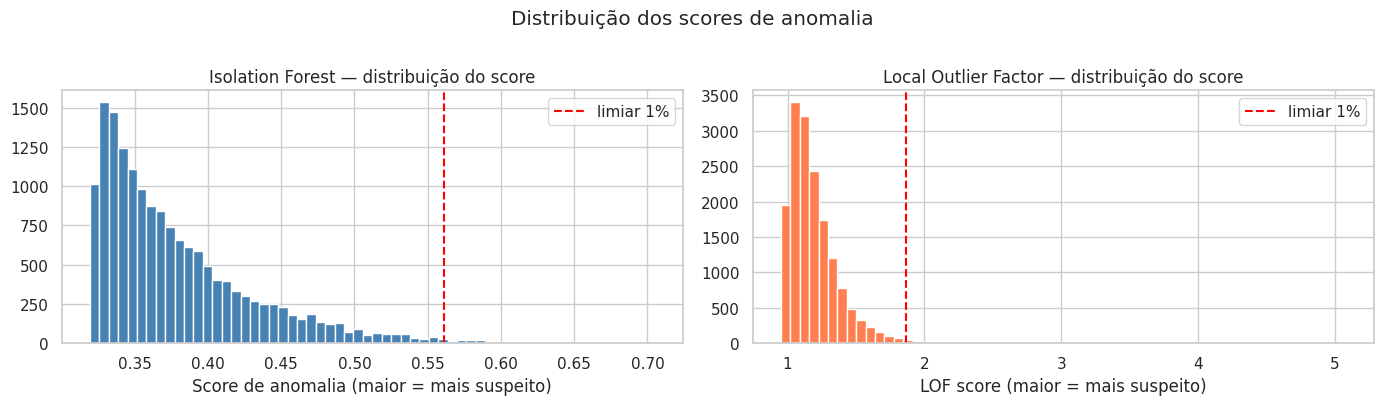

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

thr_iso = np.percentile(score_iso, 100 * (1 - CONTAM))
axes[0].hist(score_iso, bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(thr_iso, color="red", linestyle="--", label=f"limiar {CONTAM:.0%}")
axes[0].set_title("Isolation Forest — distribuição do score")
axes[0].set_xlabel("Score de anomalia (maior = mais suspeito)")
axes[0].legend()

thr_lof = np.percentile(score_lof, 100 * (1 - CONTAM))
axes[1].hist(score_lof, bins=60, color="coral", edgecolor="white")
axes[1].axvline(thr_lof, color="red", linestyle="--", label=f"limiar {CONTAM:.0%}")
axes[1].set_title("Local Outlier Factor — distribuição do score")
axes[1].set_xlabel("LOF score (maior = mais suspeito)")
axes[1].legend()

plt.suptitle("Distribuição dos scores de anomalia", y=1.01)
plt.tight_layout()
plt.show()

In [93]:
# Concordância entre os dois modelos
concord = pd.crosstab(
    pd.Series(labels_iso  == -1, name="Isolation Forest"),
    pd.Series(labels_lof == -1, name="LOF"),
)
print("Concordância entre modelos (True = anômalo):")
display(concord)

Concordância entre modelos (True = anômalo):


LOF,False,True
Isolation Forest,,
False,15962,131
True,131,32


## 8.1 Análise dos resultados iniciais

**Distribuição dos scores (dois gráficos acima):**

Cada gráfico mostra a frequência de cada faixa de score de anomalia. O eixo horizontal é o score, maior significa mais suspeito; o eixo vertical é o número de fundos. A linha vermelha tracejada marca o limiar: fundos à direita recebem o rótulo de anômalo.

O resultado esperado é uma distribuição com cauda à direita: a maioria dos fundos recebe score baixo, e poucos recebem score alto. Isso confirma que o modelo identifica casos raros.

Os dois gráficos permitem comparar Isolation Forest e LOF. Distribuições com formato parecido indicam que os dois algoritmos identificam padrões semelhantes nos dados.

**Tabela de concordância:**

- **Sinalizados por ambos:** maior confiança na detecção. Dois métodos com perspectivas diferentes chegam à mesma conclusão.
- **Sinalizados por apenas um:** merecem atenção, com menor certeza.
- **Discordâncias são esperadas:** o Isolation Forest detecta pontos raros em relação a toda a população; o LOF detecta pontos raros em relação aos vizinhos próximos. As duas perspectivas se complementam.

**Baseline vs. modelos ML:** o z-score univariado sinaliza 12,8% dos fundos, 2.085 casos. Isolation Forest e LOF sinalizam 1,0% cada, 163 fundos. O z-score sinaliza fundos com apenas um indicador extremo; não exige combinação suspeita entre vários indicadores.

# 9. Validação e otimização de hiperparâmetros (contaminações)


In [94]:
contaminacoes = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
busca = []

for c in contaminacoes:
    iso_c = IsolationForest(contamination=c, n_estimators=100, random_state=SEED)
    iso_c.fit(X)
    scores_c = -iso_c.score_samples(X)
    limiar_c = np.percentile(scores_c, 100 * (1 - c))
    flagged  = (scores_c >= limiar_c)
    busca.append({
        "contamination"        : c,
        "fundos_flagged"       : int(flagged.sum()),
        "score_medio_flagged"  : round(scores_c[flagged].mean(), 4),
        "score_minimo_flagged" : round(scores_c[flagged].min(),  4),
    })

In [95]:
df_busca = pd.DataFrame(busca)
display(df_busca)

,contamination,fundos_flagged,score_medio_flagged,score_minimo_flagged
0,0.01,163,0.5985,0.5614
1,0.02,326,0.5726,0.5337
2,0.05,813,0.5349,0.4897
3,0.10,1626,0.5031,0.4557
4,0.15,2439,0.4836,0.4339
5,0.20,3252,0.4689,0.4167


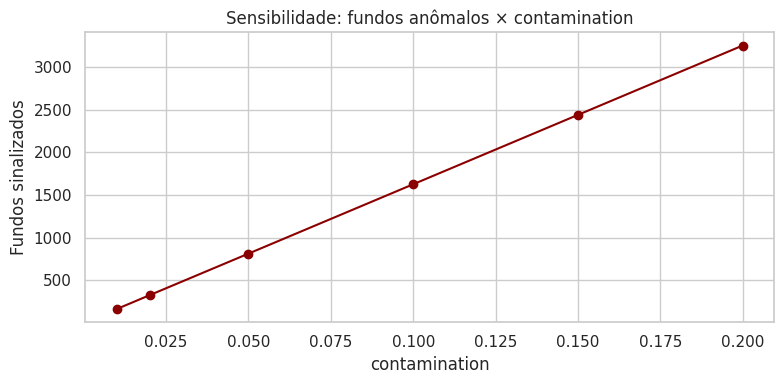

In [96]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_busca["contamination"], df_busca["fundos_flagged"], marker="o", color="darkred")
ax.set_xlabel("contamination")
ax.set_ylabel("Fundos sinalizados")
ax.set_title("Sensibilidade: fundos anômalos × contamination")
plt.tight_layout()
plt.show()

In [97]:
BEST_CONTAM = 0.01
iso_final   = IsolationForest(contamination=BEST_CONTAM, n_estimators=200, random_state=SEED)
iso_final.fit(X)
labels_final = iso_final.predict(X)
score_final  = -iso_final.score_samples(X)
print(f"\nModelo final: contamination={BEST_CONTAM}, n_estimators=200")
print(f"Fundos sinalizados: {(labels_final == -1).sum():,}")


Modelo final: contamination=0.01, n_estimators=200
Fundos sinalizados: 163


## 9.1 Discussão da otimização

O hiperparâmetro `contamination` define a fração esperada de anomalias. Sem rótulos, o analista não otimiza esse valor por uma métrica objetiva. A análise de sensibilidade acima orienta a escolha.

**Como ler o gráfico:**
O eixo horizontal é o valor de `contamination`; o eixo vertical é o número de fundos sinalizados. A relação é linear: dobrar `contamination` dobra o número de fundos sinalizados. Os scores não mudam; o modelo reposiciona o limiar no ranking.

**Como ler a tabela:**
- `score_minimo_flagged`: à medida que `contamination` sobe, o modelo passa a incluir fundos com scores menores. Se esse valor cair perto da mediana, o modelo está sinalizando fundos que não são atípicos.
- `score_medio_flagged`: deve permanecer alto mesmo com `contamination` maior. Uma queda rápida indica diluição do sinal.

**Por que `contamination = 0.01`:** a base final tem cerca de 16.000 fundos, depois dos filtros de qualidade, situação e feeder. 1% corresponde a cerca de 160 casos. O foco nos casos mais extremos reduz o volume de revisão. Para cobertura maior, use 0.025 (500 fundos) ou 0.05 (1.000 fundos); os scores não mudam, só o limiar de corte.

**Por que `n_estimators = 200`:** o dobro do padrão, 100, aumenta a estabilidade do score sem custo de execução significativo.

# 10. Avaliação final no conjunto de teste


In [98]:
anomalo = labels_final == -1

pca = PCA(n_components=2, random_state=SEED)
X2  = pca.fit_transform(X)
var = pca.explained_variance_ratio_

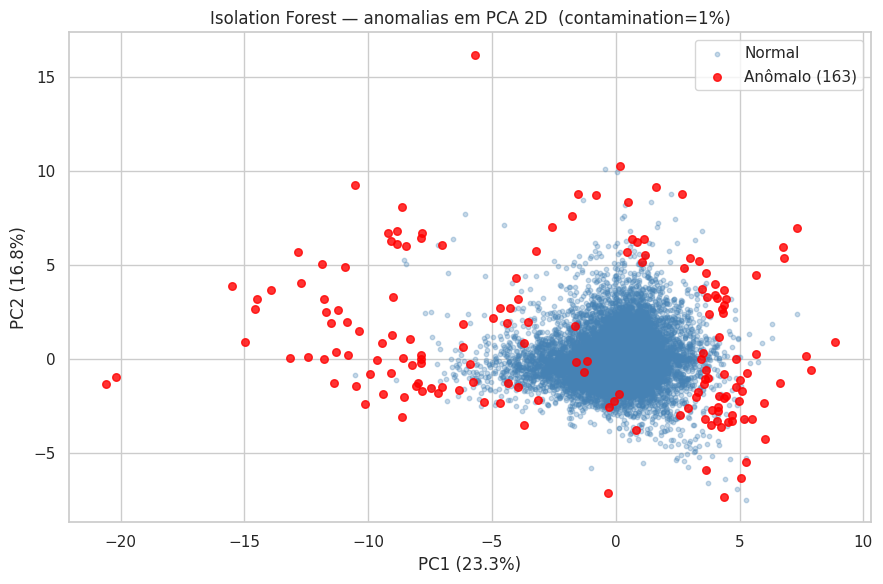

In [99]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X2[~anomalo, 0], X2[~anomalo, 1], s=10, alpha=0.3, color="steelblue", label="Normal")
ax.scatter(X2[ anomalo, 0], X2[ anomalo, 1], s=30, alpha=0.8, color="red",       label=f"Anômalo ({anomalo.sum():,})")
ax.set_xlabel(f"PC1 ({var[0]:.1%})")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
ax.set_title(f"Isolation Forest — anomalias em PCA 2D  (contamination={BEST_CONTAM:.0%})")
ax.legend()
plt.tight_layout()
plt.show()

In [100]:
# Incluir metadados do cadastro CVM se disponíveis
meta_cols = [c for c in ["nome", "situacao", "tipo", "publico_alvo"] if c in features.columns]
resultado = features[["CNPJ_FUNDO_CLASSE"] + FEATURE_COLS + meta_cols].copy()
resultado["score_anomalia"] = score_final
resultado["anomalo"]        = anomalo

In [101]:
print("=== Top 20 fundos mais anômalos ===")
display(resultado.sort_values("score_anomalia", ascending=False).head(20)
        .reset_index(drop=True).round(4))

=== Top 20 fundos mais anômalos ===


,CNPJ_FUNDO_CLASSE,volatilidade,retorno_total,max_drawdown,sharpe,log_pl,fluxo_medio,prop_fluxo_neg,tendencia_pl,tendencia_cotistas,log_cotistas,nome,situacao,tipo,publico_alvo,score_anomalia,anomalo
0,10.424.371/0001-54,0.0218,-0.3295,-0.3376,-15.1313,16.2560,-4.366941e+05,0.0062,-8.1103,-0.9163,0.7558,SANTANDER SOVEREIGN CIC DE CLASSES DE INVESTIM...,Em Funcionamento Normal,Renda Fixa Duração Baixa Soberano,Público Geral,0.7002,True
1,36.436.936/0001-07,0.6512,-1.0000,-1.0000,-1.5357,19.1417,-3.459962e+05,0.0263,-19.1677,-3.4340,3.3012,RADAR 360 FUNDO DE INVESTIMENTO FINANCEIRO EM ...,Em Funcionamento Normal,Ações Livre,Qualificado,0.6792,True
2,06.084.858/0001-68,0.6433,-1.0000,-1.0000,-1.5544,16.1947,-5.002536e+03,0.3493,-16.2665,-6.3099,6.1940,SANTANDER ÍNDICE BOVESPA AÇÕES - CIC FIF RESP ...,Em Funcionamento Normal,Ações Indexados,Público Geral,0.6692,True
3,42.101.954/0001-30,0.6456,-1.0000,-1.0000,-1.5489,16.2288,-2.096316e+04,0.5595,-15.9263,-7.1785,7.3664,WELLINGTON S&P 500 BRL CLASSE DE INVESTIMENTO...,Em Funcionamento Normal,Ações Livre,Público Geral,0.6690,True
4,22.918.245/0001-35,0.6244,-1.0000,-1.0000,-1.6016,17.8194,8.138627e+03,0.5239,-17.5379,-8.6410,8.9977,SANTANDER SIMPLES RENDA FIXA - CIC FIF RESP LI...,Em Funcionamento Normal,Renda Fixa Simples,Público Geral,0.6632,True
5,11.902.276/0001-81,3.1856,-0.6560,-0.9059,-0.2059,15.0398,0.000000e+00,0.0000,-1.0672,0.0000,2.9957,FUNDO DE INVESTIMENTO FINANCEIRO RECUPERAÇÃO B...,Em Funcionamento Normal,Renda Fixa Duração Livre Grau de Invest.,Profissional,0.6630,True
6,28.386.252/0001-10,0.6254,-1.0000,-1.0000,-1.5991,17.5148,-1.531353e+05,0.7632,-18.2898,-1.7918,1.8028,GIANT C FUNDO DE INVESTIMENTO FINANCEIRO RENDA...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Público Geral,0.6624,True
7,26.470.457/0001-53,0.0530,0.1053,-0.1043,1.9868,20.4928,-2.527490e+06,0.3272,-1.8597,-2.0498,4.3980,ITAÚ VÉRTICE FOF INFLAÇÃO RENDA FIXA FUNDO DE ...,Em Funcionamento Normal,Renda Fixa Duração Livre Soberano,Profissional,0.6584,True
8,30.998.075/0001-74,0.6522,-1.0000,-1.0000,-1.5333,18.3018,-7.697886e+04,0.0231,-18.7583,-3.1355,2.9629,TRUXT III VALOR FIF DA CIC EM AÇÕES RESPONSABI...,Em Funcionamento Normal,Ações Livre,Público Geral,0.6573,True
9,17.518.976/0001-53,0.0011,0.3639,0.0000,343.7396,22.9480,-1.046645e+07,0.5697,-0.5532,-0.8708,3.4815,VIVEST CAIXA FIF - CI MULTIMERCADO - CRÉDITO P...,Em Funcionamento Normal,Multimercados Livre,Profissional,0.6550,True


In [102]:
print("\n=== Perfil médio: anômalos vs normais ===")
display(resultado.groupby("anomalo")[FEATURE_COLS].mean().round(4)
        .rename(index={False: "Normal", True: "Anômalo"}))


=== Perfil médio: anômalos vs normais ===


,volatilidade,retorno_total,max_drawdown,sharpe,log_pl,fluxo_medio,prop_fluxo_neg,tendencia_pl,tendencia_cotistas,log_cotistas
anomalo,,,,,,,,,,
Normal,0.0956,0.2892,-0.1123,37.0611,18.045,-44092.9367,0.1733,0.0349,0.0162,2.2633
Anômalo,0.5099,0.5302,-0.3773,61.7496,19.120,738092.2583,0.2570,-2.2614,-0.1248,3.2034


## 10.1 Tipos de anomalia e validação contra o cadastro CVM

**Gráfico de dispersão PCA 2D:**

O gráfico projeta os 10 indicadores em 2 dimensões usando PCA. O PCA encontra as duas direções de maior variação nos dados e projeta todos os fundos nessas direções.

Cada ponto é um fundo. Pontos azuis são normais; pontos vermelhos são anômalos. Os percentuais nos eixos, PC1 e PC2, indicam quanto da variação total cada eixo captura. Fundos anômalos tendem a ocupar as bordas, afastados do grupo central.

**Os três tipos de anomalia:**

- **Estresse de performance:** drawdown severo, retorno total negativo ou volatilidade extrema.
- **Estresse de fluxo:** alta proporção de dias com resgate superior à captação e fluxo líquido médio muito negativo.
- **Declínio estrutural:** queda de PL e cotistas ao longo do período, patrimônio muito baixo. Pode indicar esvaziamento anterior ao encerramento formal.

**Mapa de calor dos Top 20 (heatmap):**

Cada linha é um fundo; cada coluna é uma dimensão de estresse. Cor vermelha indica desvio do padrão naquela dimensão. Fundos com vermelho em múltiplas colunas têm prioridade maior para revisão.

**Validação retroativa contra o cadastro CVM:**

- A base de treino (seção 5.3) usa só fundos `situacao == "Em Funcionamento Normal"`. Por isso, comparar a proporção de "Em Liquidação"/"Cancelado" entre sinalizados e normais dentro do próprio `resultado` não funciona: o processo já removeu esses casos antes da modelagem, e a comparação daria 100% "Em Funcionamento Normal" nos dois grupos, sem nenhum sinal.
- Em vez disso, os fundos "Em Liquidação"/"Cancelado" (seção 5.3) formam um **holdout de validação retroativa**: ficam fora do treino e da normalização peer group, mas o pipeline e o Isolation Forest já ajustados os pontuam, reaplicando a mesma normalização do treino via `normalizar_peer_group` (seção 6).
- Se o score médio e a taxa de flag desse holdout forem bem maiores que os da base de treino, o modelo captura sinal real de dificuldade financeira sem que essa informação tenha entrado no treinamento. É uma validação legítima: o holdout nunca influenciou as medianas e desvios de normalização, nem o ajuste do Isolation Forest.

In [103]:
# --- Categorizar tipo de anomalia (vetorizado) ---
X_std = pd.DataFrame(X, columns=FEATURE_COLS)

perf_score   = X_std[["max_drawdown", "retorno_total", "volatilidade", "sharpe"]].abs().max(axis=1)
flow_score   = X_std[["prop_fluxo_neg", "fluxo_medio"]].abs().max(axis=1)
struct_score = X_std[["tendencia_pl", "tendencia_cotistas", "log_cotistas"]].abs().max(axis=1)

tipo_scores = pd.DataFrame({
    "Estresse de performance": perf_score,
    "Estresse de fluxo"     : flow_score,
    "Declínio estrutural"   : struct_score,
})
resultado["tipo_anomalia"] = np.where(anomalo, tipo_scores.idxmax(axis=1), "Normal")

print("Tipos de anomalia identificados:")
display(resultado[resultado["anomalo"]]["tipo_anomalia"].value_counts())

Tipos de anomalia identificados:


,count
tipo_anomalia,
Estresse de performance,76
Declínio estrutural,45
Estresse de fluxo,42


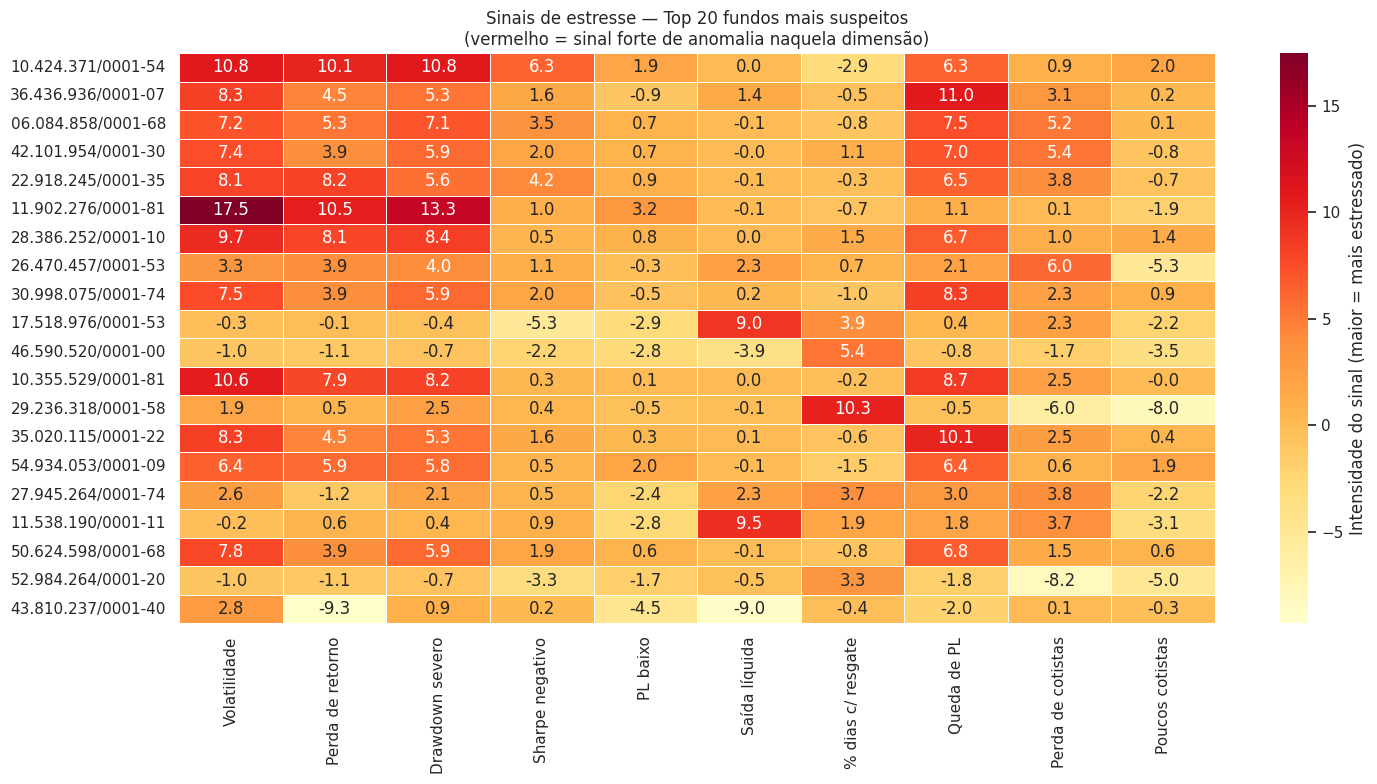

In [104]:
# --- Heatmap: top 20 fundos mais suspeitos ---
top20     = resultado.sort_values("score_anomalia", ascending=False).head(20)
heat_data = X_std.iloc[top20.index].copy()

# Inverter sinal para que "alto = mais estressado" em todas as colunas
STRESS_DIR = {
    "volatilidade": 1, "retorno_total": -1, "max_drawdown": -1, "sharpe": -1,
    "log_pl": -1, "fluxo_medio": -1, "prop_fluxo_neg": 1,
    "tendencia_pl": -1, "tendencia_cotistas": -1, "log_cotistas": -1,
}
for col, sign in STRESS_DIR.items():
    heat_data[col] *= sign

heat_data.columns = [
    "Volatilidade", "Perda de retorno", "Drawdown severo", "Sharpe negativo",
    "PL baixo", "Saída líquida", "% dias c/ resgate",
    "Queda de PL", "Perda de cotistas", "Poucos cotistas",
]
heat_data.index = top20["CNPJ_FUNDO_CLASSE"].values

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(heat_data, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Intensidade do sinal (maior = mais estressado)"})
ax.set_title("Sinais de estresse — Top 20 fundos mais suspeitos\n"
             "(vermelho = sinal forte de anomalia naquela dimensão)")
plt.tight_layout()
plt.show()


=== Validação retroativa: fundos já Em Liquidação/Cancelado (fora do treino) ===
Holdout                                                : 49 fundos
Score médio — holdout (liquidados/cancelados)          : 0.5195
Score médio — base de treino (Em Funcionamento Normal) : 0.3808
Taxa de flag no mesmo limiar do treino                 : holdout 40.8%  vs.  treino 1.0%

Interpretação: score médio e taxa de flag bem maiores no holdout indicam que o
modelo captura sinal real de dificuldade financeira sem essa informação ter entrado no treino.


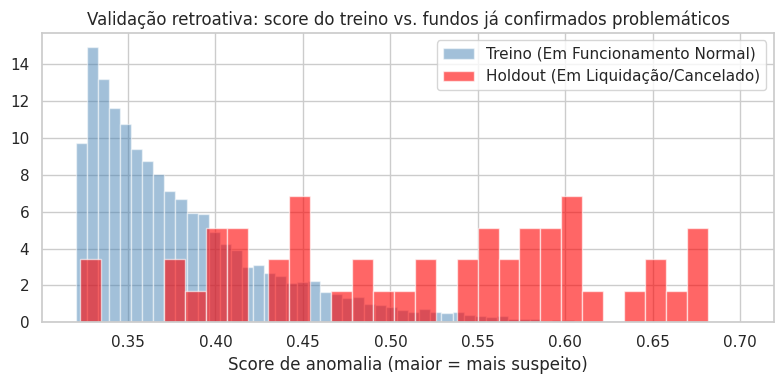

In [105]:
# --- Validação retroativa: pontuar o holdout de fundos já Em Liquidação/Cancelado ---
if len(features_liquidados) > 0:
    peer_labels_liq = features_liquidados["tipo"] + " | " + features_liquidados["publico_alvo"]
    X_liq_raw   = normalizar_peer_group(features_liquidados[FEATURE_COLS], peer_labels_liq, features_liquidados["tipo"])
    X_liq       = preproc.transform(X_liq_raw)
    score_liq   = -iso_final.score_samples(X_liq)
    anomalo_liq = iso_final.predict(X_liq) == -1

    print("\n=== Validação retroativa: fundos já Em Liquidação/Cancelado (fora do treino) ===")
    print(f"Holdout                                                : {len(features_liquidados):,} fundos")
    print(f"Score médio — holdout (liquidados/cancelados)          : {score_liq.mean():.4f}")
    print(f"Score médio — base de treino (Em Funcionamento Normal) : {score_final.mean():.4f}")
    print(f"Taxa de flag no mesmo limiar do treino                 : holdout {anomalo_liq.mean():.1%}  vs.  treino {anomalo.mean():.1%}")
    print("\nInterpretação: score médio e taxa de flag bem maiores no holdout indicam que o")
    print("modelo captura sinal real de dificuldade financeira sem essa informação ter entrado no treino.")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(score_final, bins=60, density=True, alpha=0.5, color="steelblue", label="Treino (Em Funcionamento Normal)")
    ax.hist(score_liq, bins=min(30, max(5, len(score_liq))), density=True, alpha=0.6, color="red",
            label="Holdout (Em Liquidação/Cancelado)")
    ax.set_xlabel("Score de anomalia (maior = mais suspeito)")
    ax.set_title("Validação retroativa: score do treino vs. fundos já confirmados problemáticos")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nHoldout de validação retroativa vazio — nenhum fundo Em Liquidação/Cancelado disponível nesta janela.")

## 10.2 Análise de erros e limitações

- **Ausência de rótulos verdadeiros:** sem uma lista de fundos confirmadamente problemáticos, o modelo não calcula precisão ou recall. A validação é qualitativa: os fundos sinalizados têm perfil coerente com dificuldades financeiras? A concentração de fundos "Em Liquidação" entre os anômalos é a evidência mais direta disponível.
- **`contamination` é uma premissa do analista:** o modelo ordena os fundos por score; o limiar depende do contexto de uso. Due diligence agressiva justifica `contamination` maior; equipes com recursos limitados usam 1% e revisam apenas os casos mais extremos.
- **Overfitting/underfitting no contexto não supervisionado:** os conceitos clássicos, erro em treino vs. teste, não se aplicam sem variável-alvo, mas os hiperparâmetros de complexidade do modelo têm um equivalente direto.
  - `n_estimators` controla a estabilidade do score. Poucas árvores fariam o Isolation Forest reagir ao ruído da amostragem, e o score de um mesmo fundo mudaria a cada execução. Com `n_estimators = 200` (seção 9.1), o score estabiliza sem custo de execução relevante.
  - `contamination` funciona como o eixo equivalente a subajuste e sobreajuste do limiar de decisão. Um valor baixo demais super-especializa o modelo em pouquíssimos casos extremos e pode deixar de fora anomalias reais, um underfitting do escopo de detecção. Um valor alto demais dilui o sinal e passa a sinalizar fundos apenas levemente atípicos, essencialmente ruído, um overfitting à cauda da distribuição.
  - A tabela de sensibilidade da seção 9 evidencia esse trade-off: `score_medio_flagged` cai à medida que `contamination` sobe.
- **LOF não suporta `predict()` em novos dados:** `LocalOutlierFactor` com `novelty=False` exige re-treino completo para classificar novos fundos. Para uso em produção, apenas o Isolation Forest funciona.
- **Agregação perde granularidade temporal:** dois fundos com o mesmo score podem ter chegado a ele por caminhos diferentes. Uma queda abrupta em uma semana e um declínio gradual ao longo de dois anos produzem indicadores parecidos, mas exigem respostas distintas.
- **Erros de reporte residuais:** o filtro da seção 5.1 remove os casos mais extremos. Erros mais sutis, cotas que oscilam por alguns dias e voltam ao normal, passam pelo filtro e podem gerar falsos positivos pontuais.

## 10.3 Isolation Forest por peer group (categoria ANBIMA × público-alvo)

A análise global compara todos os fundos juntos. Um fundo de ações com volatilidade alta recebe score alto ao lado de fundos de renda fixa, mesmo que esse nível de volatilidade seja normal dentro da categoria "Ações Livre". Da mesma forma, um fundo Profissional com resgate concentrado pareceria anômalo ao lado de fundos abertos ao Público Geral, mesmo sendo comportamento normal para esse tipo de investidor.

O Isolation Forest roda separadamente dentro de cada peer group (combinação de categoria ANBIMA e público-alvo) com 50 ou mais fundos. Fundos sinalizados em ambas as análises, global e peer, demonstram comportamento atípico por dois critérios distintos. Esses casos formam a lista de prioridade máxima para revisão.

In [106]:
MIN_PEER_MODELAGEM = 50
GROUP_KEY = "peer_group" if "peer_group" in features.columns else ("tipo" if "tipo" in features.columns else None)
grupos_validos = (features[GROUP_KEY].value_counts()
                  .loc[lambda s: s >= MIN_PEER_MODELAGEM].index.tolist()
                  if GROUP_KEY else [])

In [107]:
if not grupos_validos:
    print("Cadastro CVM não disponível — execute a seção 3.5 primeiro.")
else:
    print(f"Peer groups (categoria ANBIMA × público-alvo) com ≥ {MIN_PEER_MODELAGEM} fundos: {len(grupos_validos)}")
    for grp in grupos_validos:
        print(f"  {grp}: {(features[GROUP_KEY] == grp).sum():,} fundos")

    resultado["peer_anomalo"] = False
    resultado["peer_score"]   = np.nan

    for grp in grupos_validos:
        mask    = (features[GROUP_KEY] == grp).values
        X_cat   = X[mask]
        iso_cat = IsolationForest(contamination=BEST_CONTAM, n_estimators=100, random_state=SEED)
        iso_cat.fit(X_cat)
        idx_cat = np.where(mask)[0]
        resultado.iloc[idx_cat, resultado.columns.get_loc("peer_anomalo")] = iso_cat.predict(X_cat) == -1
        resultado.iloc[idx_cat, resultado.columns.get_loc("peer_score")]   = -iso_cat.score_samples(X_cat)

    global_only = resultado["anomalo"]  & ~resultado["peer_anomalo"]
    peer_only   = ~resultado["anomalo"] & resultado["peer_anomalo"]
    ambos       = resultado["anomalo"]  & resultado["peer_anomalo"]

    print(f"\nAnômalo só na análise global       : {global_only.sum():,} fundos")
    print(f"Anômalo só na análise por peers    : {peer_only.sum():,} fundos")
    print(f"Anômalo em AMBAS as análises       : {ambos.sum():,} fundos")

    colunas_show = ["CNPJ_FUNDO_CLASSE"] + meta_cols + ["tipo_anomalia", "score_anomalia", "peer_score"]
    colunas_show = [c for c in colunas_show if c in resultado.columns]
    print("\n=== Top 15 fundos de maior prioridade (anômalos em ambas as análises) ===")
    display(resultado[ambos].sort_values("score_anomalia", ascending=False)
            .head(15)[colunas_show].reset_index(drop=True).round(4))

Peer groups (categoria ANBIMA × público-alvo) com ≥ 50 fundos: 46
  Multimercados Invest. no Exterior | Profissional: 3,651 fundos
  Previdência Multimercado Livre | Profissional: 1,712 fundos
  Multimercados Livre | Profissional: 1,440 fundos
  Ações Invest. no Exterior | Profissional: 647 fundos
  Renda Fixa Duração Livre Crédito Livre | Profissional: 627 fundos
  Ações Livre | Qualificado: 565 fundos
  Multimercados Livre | Público Geral: 561 fundos
  Multimercados Livre | Qualificado: 452 fundos
  Ações Livre | Público Geral: 431 fundos
  Renda Fixa Duração Livre Grau de Invest. | Profissional: 325 fundos
  Renda Fixa Duração Livre Crédito Livre | Público Geral: 307 fundos
  Multimercados Macro | Público Geral: 278 fundos
  Ações Livre | Profissional: 276 fundos
  Renda Fixa Duração Livre Grau de Invest. | Público Geral: 238 fundos
  Previdência RF Duração Livre Crédito Liv | Profissional: 233 fundos
  Multimercados Invest. no Exterior | Qualificado: 224 fundos
  Previdência RF Dur

,CNPJ_FUNDO_CLASSE,nome,situacao,tipo,publico_alvo,tipo_anomalia,score_anomalia,peer_score
0,10.424.371/0001-54,SANTANDER SOVEREIGN CIC DE CLASSES DE INVESTIM...,Em Funcionamento Normal,Renda Fixa Duração Baixa Soberano,Público Geral,Estresse de performance,0.7002,0.8234
1,36.436.936/0001-07,RADAR 360 FUNDO DE INVESTIMENTO FINANCEIRO EM ...,Em Funcionamento Normal,Ações Livre,Qualificado,Declínio estrutural,0.6792,0.7279
2,06.084.858/0001-68,SANTANDER ÍNDICE BOVESPA AÇÕES - CIC FIF RESP ...,Em Funcionamento Normal,Ações Indexados,Público Geral,Declínio estrutural,0.6692,0.7707
3,42.101.954/0001-30,WELLINGTON S&P 500 BRL CLASSE DE INVESTIMENTO...,Em Funcionamento Normal,Ações Livre,Público Geral,Estresse de performance,0.6690,0.7161
4,22.918.245/0001-35,SANTANDER SIMPLES RENDA FIXA - CIC FIF RESP LI...,Em Funcionamento Normal,Renda Fixa Simples,Público Geral,Estresse de performance,0.6632,0.8037
5,11.902.276/0001-81,FUNDO DE INVESTIMENTO FINANCEIRO RECUPERAÇÃO B...,Em Funcionamento Normal,Renda Fixa Duração Livre Grau de Invest.,Profissional,Estresse de performance,0.6630,0.7684
6,28.386.252/0001-10,GIANT C FUNDO DE INVESTIMENTO FINANCEIRO RENDA...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Público Geral,Estresse de performance,0.6624,0.7705
7,26.470.457/0001-53,ITAÚ VÉRTICE FOF INFLAÇÃO RENDA FIXA FUNDO DE ...,Em Funcionamento Normal,Renda Fixa Duração Livre Soberano,Profissional,Declínio estrutural,0.6584,0.7243
8,30.998.075/0001-74,TRUXT III VALOR FIF DA CIC EM AÇÕES RESPONSABI...,Em Funcionamento Normal,Ações Livre,Público Geral,Declínio estrutural,0.6573,0.7068
9,17.518.976/0001-53,VIVEST CAIXA FIF - CI MULTIMERCADO - CRÉDITO P...,Em Funcionamento Normal,Multimercados Livre,Profissional,Estresse de fluxo,0.6550,0.6967


## 10.4 Separação entre estresse e outliers positivos

O Isolation Forest detecta **isolamento**, não problema. Um fundo com retorno muito acima da mediana e patrimônio crescendo também ocupa um ponto isolado no espaço de features, e o modelo pode sinalizá-lo como anômalo mesmo sem nenhum sinal de estresse.

A solução não é excluir esses casos. O código os separa em duas listas com finalidades distintas:

- **`resultado_stress`:** fundos anômalos onde `retorno_total` ou `tendencia_pl` está abaixo da mediana do mercado. Candidatos a due diligence por dificuldade financeira.
- **`resultado_outlier_positivo`:** fundos anômalos onde `retorno_total` **e** `tendencia_pl` estão ambos acima da mediana. Candidatos a revisão de consistência de retorno.

**Por que manter a segunda lista?** Retorno consistentemente acima da mediana combinado com captação crescente é o padrão de um fundo saudável. É também o padrão clássico de fraude ou erro de marcação de cota, em que esquemas mostram retorno artificialmente liso e patrimônio crescente puxado por uma performance que não bate com o risco declarado. Excluir esses casos eliminaria exatamente o tipo de situação que merece um segundo olhar, com outra motivação: confirmar que a performance é legítima.

Cada lista serve a um time diferente: `resultado_stress` serve risco e due diligence de problemas operacionais; `resultado_outlier_positivo` serve seleção de fundos e verificação de consistência de retorno.

In [108]:
med_retorno = resultado["retorno_total"].median()
med_pl      = resultado["tendencia_pl"].median()

bom_outlier = (
    resultado["anomalo"] &
    (resultado["retorno_total"] > med_retorno) &
    (resultado["tendencia_pl"]  > med_pl)
)

resultado_stress           = resultado[resultado["anomalo"] & ~bom_outlier].copy()
resultado_outlier_positivo = resultado[bom_outlier].copy()

In [109]:
ROTULOS_POSITIVO = {
    "Estresse de performance" : "Retorno atípico positivo",
    "Estresse de fluxo"       : "Captação atípica",
    "Declínio estrutural"     : "Crescimento estrutural atípico",
}
resultado_outlier_positivo["tipo_anomalia"] = (
    resultado_outlier_positivo["tipo_anomalia"].map(ROTULOS_POSITIVO)
)

In [110]:
print(f"Mediana retorno_total (todos os fundos) : {med_retorno:.4f}")
print(f"Mediana tendencia_pl  (todos os fundos) : {med_pl:.4f}")
print(f"\nFundos sinalizados originalmente        : {resultado['anomalo'].sum():,}")
print(f"  -> resultado_stress                   : {len(resultado_stress):,}  (estresse financeiro)")
print(f"  -> resultado_outlier_positivo         : {len(resultado_outlier_positivo):,}  (performance atipica positiva)")

colunas_show = ["CNPJ_FUNDO_CLASSE"] + meta_cols + ["tipo_anomalia", "score_anomalia"]
colunas_show = [c for c in colunas_show if c in resultado.columns]

Mediana retorno_total (todos os fundos) : 0.2995
Mediana tendencia_pl  (todos os fundos) : 0.0457

Fundos sinalizados originalmente        : 163
  -> resultado_stress                   : 97  (estresse financeiro)
  -> resultado_outlier_positivo         : 66  (performance atipica positiva)


In [111]:
print("\n=== Top 20 — resultado_stress (due diligence por dificuldade financeira) ===")
display(resultado_stress.sort_values("score_anomalia", ascending=False)
        .head(20)[colunas_show].reset_index(drop=True).round(4))

print("\nDistribuicao por tipo de anomalia — resultado_stress:")
display(resultado_stress["tipo_anomalia"].value_counts())


=== Top 20 — resultado_stress (due diligence por dificuldade financeira) ===


,CNPJ_FUNDO_CLASSE,nome,situacao,tipo,publico_alvo,tipo_anomalia,score_anomalia
0,10.424.371/0001-54,SANTANDER SOVEREIGN CIC DE CLASSES DE INVESTIM...,Em Funcionamento Normal,Renda Fixa Duração Baixa Soberano,Público Geral,Estresse de performance,0.7002
1,36.436.936/0001-07,RADAR 360 FUNDO DE INVESTIMENTO FINANCEIRO EM ...,Em Funcionamento Normal,Ações Livre,Qualificado,Declínio estrutural,0.6792
2,06.084.858/0001-68,SANTANDER ÍNDICE BOVESPA AÇÕES - CIC FIF RESP ...,Em Funcionamento Normal,Ações Indexados,Público Geral,Declínio estrutural,0.6692
3,42.101.954/0001-30,WELLINGTON S&P 500 BRL CLASSE DE INVESTIMENTO...,Em Funcionamento Normal,Ações Livre,Público Geral,Estresse de performance,0.6690
4,22.918.245/0001-35,SANTANDER SIMPLES RENDA FIXA - CIC FIF RESP LI...,Em Funcionamento Normal,Renda Fixa Simples,Público Geral,Estresse de performance,0.6632
5,11.902.276/0001-81,FUNDO DE INVESTIMENTO FINANCEIRO RECUPERAÇÃO B...,Em Funcionamento Normal,Renda Fixa Duração Livre Grau de Invest.,Profissional,Estresse de performance,0.6630
6,28.386.252/0001-10,GIANT C FUNDO DE INVESTIMENTO FINANCEIRO RENDA...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Público Geral,Estresse de performance,0.6624
7,26.470.457/0001-53,ITAÚ VÉRTICE FOF INFLAÇÃO RENDA FIXA FUNDO DE ...,Em Funcionamento Normal,Renda Fixa Duração Livre Soberano,Profissional,Declínio estrutural,0.6584
8,30.998.075/0001-74,TRUXT III VALOR FIF DA CIC EM AÇÕES RESPONSABI...,Em Funcionamento Normal,Ações Livre,Público Geral,Declínio estrutural,0.6573
9,17.518.976/0001-53,VIVEST CAIXA FIF - CI MULTIMERCADO - CRÉDITO P...,Em Funcionamento Normal,Multimercados Livre,Profissional,Estresse de fluxo,0.6550



Distribuicao por tipo de anomalia — resultado_stress:


,count
tipo_anomalia,
Estresse de performance,47
Declínio estrutural,30
Estresse de fluxo,20


In [112]:
print("\n=== Top 20 — resultado_outlier_positivo (verificar legitimidade da performance) ===")
display(resultado_outlier_positivo.sort_values("score_anomalia", ascending=False)
        .head(20)[colunas_show].reset_index(drop=True).round(4))

print("\nDistribuicao por tipo de anomalia — resultado_outlier_positivo:")
display(resultado_outlier_positivo["tipo_anomalia"].value_counts())


=== Top 20 — resultado_outlier_positivo (verificar legitimidade da performance) ===


,CNPJ_FUNDO_CLASSE,nome,situacao,tipo,publico_alvo,tipo_anomalia,score_anomalia
0,46.590.520/0001-00,DOMUS VENTIS FUNDO DE INVESTIMENTO FINANCEIRO ...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Profissional,Captação atípica,0.6527
1,52.984.264/0001-20,ECI FUNDO DE INVESTIMENTO FINANCEIRO RENDA FIX...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Profissional,Crescimento estrutural atípico,0.6380
2,43.810.237/0001-40,MAIA 95 FUNDO DE INVESTIMENTO FINANCEIRO MULT...,Em Funcionamento Normal,Multimercados Invest. no Exterior,Profissional,Retorno atípico positivo,0.6350
3,28.671.705/0001-50,FUNDO DE INVESTIMENTO LIQUIDEZ CÂMARA B3 MULTI...,Em Funcionamento Normal,Multimercados Invest. no Exterior,Profissional,Retorno atípico positivo,0.6344
4,12.483.967/0001-50,JUPITER FUNDO DE INVESTIMENTO FINANCEIRO CLASS...,Em Funcionamento Normal,Multimercados Invest. no Exterior,Profissional,Captação atípica,0.6333
5,35.927.331/0001-56,SPARTA PREVIDENCIA FIFE D45 FUNDO DE INVESTIME...,Em Funcionamento Normal,Previdência RF Duração Média Grau de Inv,Profissional,Crescimento estrutural atípico,0.6317
6,18.808.146/0001-23,SAFIRA FUNDO DE INVESTIMENTO FINANCEIRO RENDA ...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Profissional,Captação atípica,0.6315
7,08.999.309/0001-49,ANGOPHORA FUNDO DE INVESTIMENTO FINANCEIRO,Em Funcionamento Normal,Renda Fixa Duração Baixa Soberano,Profissional,Retorno atípico positivo,0.6232
8,49.980.566/0001-16,ITAÚ FLEXPREV ADVANCED FIF MULT CRED PRIV - RE...,Em Funcionamento Normal,Previdência Multimercado Livre,Profissional,Captação atípica,0.6217
9,54.755.971/0001-70,ITAÚ PIRINEUS II PRIVATE MARKETS FIF INCENTIVA...,Em Funcionamento Normal,Renda Fixa Duração Livre Crédito Livre,Profissional,Crescimento estrutural atípico,0.6214



Distribuicao por tipo de anomalia — resultado_outlier_positivo:


,count
tipo_anomalia,
Retorno atípico positivo,29
Captação atípica,22
Crescimento estrutural atípico,15


# 11. Comparação dos modelos

Em detecção de anomalias sem rótulos, o modelo não tem métrica objetiva de desempenho. A comparação usa a interpretabilidade dos fundos sinalizados e a concordância entre abordagens.

| Modelo | Critério de flag | Fundos sinalizados | Suporta predict() | Observações |
|---|---|---:|---|---|
| Baseline (z-score, \|z\| > 3) | Um indicador individualmente extremo | 2.085 (12,8%) | Não | Ignora correlações entre indicadores |
| Isolation Forest | Score multivariado (isolabilidade) | 163 (1,0%) | Sim | Rápido; robusto em alta dimensão |
| Local Outlier Factor | Densidade local | 163 (1,0%) | Não | Detecta anomalias locais; indicado para validação |

**Modelo final: Isolation Forest.** Captura combinações multivariadas de sinais, produz score contínuo e classifica novos fundos via `predict()`.

**Fundos de alta confiança:** os fundos sinalizados por IF e por LOF são os candidatos prioritários para revisão manual.

# 12. Boas práticas e rastreabilidade

- **Seed:** `SEED = 42` em `np.random.seed(SEED)` e `random_state=SEED` no Isolation Forest. O LOF é determinístico.
- **Ambiente:** Python 3 com bibliotecas padrão do Colab. Sem dependências externas.
- **Tempo estimado:** download de 1 a 2 minutos para 30 meses (arquivos já baixados levam segundos); feature engineering de 20 a 40 segundos; modelos em menos de 30 segundos.

| Decisão | Justificativa |
|---|---|
| `usecols` na leitura | Carrega apenas as colunas necessárias; reduz RAM e tempo de leitura |
| `del df, agg; gc.collect()` | Libera o DataFrame bruto depois da agregação; evita travamento no Colab |
| **`MIN_OBS = 500`** | Exige pelo menos 2 anos de atividade na janela de 30 meses; garante robustez estatística de Sharpe, volatilidade e tendências |
| Filtro de qualidade (seção 5.1) | Remove erros de reporte antes do pipeline; evita que outliers espúrios distorçam o `StandardScaler` |
| `log1p` para PL e cotistas | Reduz assimetria severa antes da padronização |
| `prop_fluxo_neg` como média 0/1 | Vetorizado; não usa `.apply()` |
| `tendencia_pl` e `tendencia_cotistas` | Capturam declínio persistente, não o nível médio |
| **Normalização por peer group (ANBIMA × público-alvo)** | Cada fundo se compara apenas aos seus pares de risco e de público-alvo antes do `StandardScaler` global |
| `StandardScaler` | Necessário para IF e LOF, que calculam distâncias |
| `contamination = 0.01` | 1% dos fundos sinalizados, cerca de 160 casos; a tabela de sensibilidade na seção 9 orienta a calibração |
| `n_estimators = 200` | Maior estabilidade do score sem custo de execução significativo |
| IF como modelo final | Único dos três que suporta `predict()` em novos fundos |
| **Janela dez/2023 a jun/2026** | Evita distorções do choque de juros de 2021-2022; a RCVM 175 torna dez/2023 o início efetivo dos dados |
| **Holdout de validação retroativa (seção 5.3)** | Fundos Em Liquidação/Cancelado ficam fora do treino; o modelo os pontua à parte (seção 10.1), evitando comparar dentro da própria base de treino |

# 13. Conclusão

O notebook constrói um pipeline de detecção de anomalias em fundos de investimento com dados públicos da CVM, sem rótulos, sem dados proprietários e sem configuração manual.

**Dataset:** Informe Diário de Fundos de Investimento (CVM), dezembro de 2023 a junho de 2026, 30 meses, mais o cadastro `registro_classe.csv` com nome, situação, categoria ANBIMA e público-alvo de cada fundo.

**Feature engineering:** 10 indicadores por fundo em quatro dimensões: performance ajustada por risco (volatilidade, retorno total, max_drawdown, sharpe), porte (log_pl), fluxo (fluxo_medio, prop_fluxo_neg) e tendência (tendencia_pl, tendencia_cotistas, log_cotistas).

**Modelos avaliados:**
1. **Baseline (z-score):** flag por indicador isolado. Modelo de referência.
2. **Isolation Forest:** score multivariado por isolabilidade. Modelo principal.
3. **Local Outlier Factor:** score por densidade local. Validação cruzada.

**Modelo escolhido:** Isolation Forest com `contamination = 0.01` e `n_estimators = 200`.

**Principais decisões de projeto:**
- **Recorte temporal (seção 3.2):** dezembro de 2023 marca o início dos informes no formato da Resolução CVM 175. A janela evita o choque de juros de 2021-2022, quando distorções macroeconômicas gerariam anomalias sem relação com a gestão dos fundos.
- **`MIN_OBS = 500` (seção 5):** o fundo precisa ter dados em 79% da janela de 30 meses. Isso garante robustez estatística de Sharpe, volatilidade e tendências.
- **Normalização por peer group ANBIMA × público-alvo (seção 6):** cada fundo se compara aos pares de mesma categoria e mesmo público-alvo antes da padronização global. Isso elimina o viés entre renda fixa, multimercado e ações, e entre investidor de varejo e profissional/qualificado.
- **`contamination = 0.01` (seção 9):** sinaliza 1% dos fundos, cerca de 160 casos. A tabela de sensibilidade na seção 9 orienta a calibração conforme a capacidade da equipe.
- **Cadastro CVM (seção 3.5):** adiciona nome, situação, categoria e público-alvo a cada fundo. Sem esse dado, o output traz apenas um CNPJ.
- **Tipo de anomalia (seção 10.1):** cada fundo sinalizado recebe o rótulo da dimensão de estresse predominante.
- **Holdout de validação retroativa (seções 5.3 e 10.1):** fundos Em Liquidação/Cancelado ficam fora do treino desde a seção 5.3, e o modelo já ajustado os pontua à parte. Um score médio e uma taxa de flag mais altos que os da base de treino confirmam que o modelo captura sinal real sem usar essa informação no ajuste.
- **Peer group (seção 10.3):** o Isolation Forest por peer group (categoria ANBIMA × público-alvo) identifica fundos atípicos dentro do próprio grupo. Os fundos sinalizados em ambas as análises formam a lista de prioridade máxima.

**Limitações:** sem rótulos para calcular precisão e recall; `contamination` depende do julgamento do analista; as features agregadas perdem granularidade temporal intraperíodo; erros de preenchimento sutis na CVM podem gerar falsos positivos.

**Próximos passos:** benchmark contra CDI e Ibovespa por regime de mercado; modelos de série temporal (autoencoder LSTM) para capturar padrões dinâmicos; monitoramento mensal automatizado.

# 14. Salvamento de artefatos

O código salva os arquivos abaixo em `cvm_mvp_data/artifacts/`:

- **`pipeline_preproc.pkl`:** pipeline de imputação e padronização. Permite transformar novos fundos com os mesmos parâmetros usados no treino.
- **`isolation_forest.pkl`:** modelo treinado. Permite classificar novos fundos via `predict()` e obter scores via `score_samples()` sem reexecutar o notebook.
- **`fundos_com_scores.csv`:** tabela completa com score de anomalia, flag e tipo de anomalia por fundo.

O notebook executa do início ao fim sem depender desses arquivos. O código gera os arquivos durante a execução, para uso externo.

In [113]:
ARTIFACTS_DIR = Path("cvm_mvp_data/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [114]:
with open(ARTIFACTS_DIR / "pipeline_preproc.pkl", "wb") as f:
    pickle.dump(preproc, f)

with open(ARTIFACTS_DIR / "isolation_forest.pkl", "wb") as f:
    pickle.dump(iso_final, f)

resultado.to_csv(ARTIFACTS_DIR / "fundos_com_scores.csv", index=False)

In [115]:
print("Artefatos salvos em:", ARTIFACTS_DIR)
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

Artefatos salvos em: cvm_mvp_data/artifacts
  fundos_com_scores.csv  (6387.8 KB)
  isolation_forest.pkl  (1410.5 KB)
  pipeline_preproc.pkl  (1.3 KB)
